In [1]:
import os
import math
import pandas as pd
import numpy as np
from collections import defaultdict, Counter
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sb
import csv
from scipy import stats
from scipy.spatial.distance import cosine
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [2]:
with open("analytics.json", "r") as f:
    analytics = eval(f.read())

In [3]:
Counter([len(i) for i in analytics['participants'][33:]])

Counter({14: 84, 12: 33, 15: 1658})

In [4]:
participants = pd.read_csv("Cleaned_study_data.csv")
participants

,StartDate_post,EndDate_post,Status_post,IPAddress_post,Progress_post,Duration (in seconds)_post,Finished_post,RecordedDate_post,ResponseId_post,RecipientLastName_post,...,ih_dwell_p,mc_correct,n_op,n_comments,zip_state_match,speeder,commented,posted,passcode,gold_star
0,12/12/2023 10:34,12/12/2023 10:37,IP Address,71.71.112.54,100,217,True,12/12/2023 10:37,R_2ARnUkZ40c702IE,NaN,...,0.220734,1,1,2,1,0,1,1,True,0
1,12/12/2023 10:46,12/12/2023 10:52,IP Address,172.58.10.215,100,374,True,12/12/2023 10:52,R_27amtKO2JE7Iho9,NaN,...,0.109973,1,1,1,1,1,1,1,True,1
2,12/12/2023 10:47,12/12/2023 10:56,IP Address,66.212.218.70,100,520,True,12/12/2023 10:56,R_2Cy58sTvdtprJbm,NaN,...,0.141557,1,1,1,1,1,1,1,True,1
3,12/12/2023 10:55,12/12/2023 11:00,IP Address,68.116.85.163,100,260,True,12/12/2023 11:00,R_3QXJjMxRbpGVqnN,NaN,...,0.036418,1,1,1,1,1,1,1,True,1
4,12/12/2023 10:52,12/12/2023 11:06,IP Address,174.215.176.210,100,885,True,12/12/2023 11:06,R_2YLnKFzaVR8F7Mj,NaN,...,0.181847,1,1,1,1,1,1,1,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1038,12/12/2023 11:18,12/12/2023 11:25,IP Address,73.3.224.41,93,434,False,12/15/2023 0:33,R_1ddeajwrFRZrG73,NaN,...,0.092647,1,1,5,1,1,1,1,True,1
1039,12/12/2023 11:59,12/12/2023 12:02,IP Address,100.40.186.229,93,189,False,12/15/2023 0:33,R_27fMb9wZPSEktas,NaN,...,0.342752,1,0,4,1,1,0,1,True,0
1040,12/12/2023 11:32,12/12/2023 11:35,IP Address,172.56.15.42,93,197,False,12/15/2023 0:33,R_2ZKzyLxSf1s9NeJ,NaN,...,0.209302,1,1,1,1,1,1,1,True,1
1041,12/13/2023 13:25,12/13/2023 13:29,IP Address,24.99.26.176,93,222,False,12/15/2023 0:33,R_15KKEVD99jKy9Di,NaN,...,0.000000,1,1,5,1,1,1,1,True,1


In [5]:
ids = set(participants.participant_code)

In [6]:
analytics = [i for i in analytics['participants'] if len(i) == 15]
analytics = [i for i in analytics if i['participantCode'].lower() in ids]
len(analytics)

1043

In [7]:
analytics[0]

{'isAutoFollowingDisabled': False,
 'following': 0,
 'followers': 2,
 'qualified': True,
 'tags': [],
 '_id': '657896b96d158d001f181516',
 'study': '654d3200f18dbd001f7a8515',
 'user': '657896b96d158d001f18150f',
 'participantCode': '8GCH37',
 'profileNumber': 173,
 '__v': 0,
 'exitSurveySchedule': '2023-12-12T17:34:10.943Z',
 'finishedOnboardingSurveyAt': '2023-12-12T17:24:10.943Z',
 'treatmentArm': '654eaf90ae0ef3001e0a82b8',
 'analytics': [{'_id': '657897506d158d001f181c53',
   'module': 'posts',
   'participant': '657896b96d158d001f181516',
   'study': '654d3200f18dbd001f7a8515',
   'meta': {'description': 'User dwell time on post',
    'timestamp': '2023-12-12T17:24:30.455Z',
    'postId': '654e2ecbf18dbd001f7aaebe',
    'dwellTimeInSeconds': 18},
   '__v': 0,
   'createdAt': '2023-12-12T17:24:32.204Z',
   'updatedAt': '2023-12-12T17:24:32.204Z'},
  {'_id': '657897506d158d001f181c54',
   'module': 'posts',
   'participant': '657896b96d158d001f181516',
   'study': '654d3200f18dbd00

In [8]:
frmt = '%Y-%m-%dT%H:%M:%S'
start_times = {i['participantCode'].lower(): datetime.strptime(i['finishedOnboardingSurveyAt'].split('.')[0], frmt) for i in analytics}

In [9]:
posts = pd.read_csv("perspective_toxicity.csv")
content = posts[posts.userContent == 1]
content = content[content.treatmentArm != "imm_pc"]
content = content[content.treatmentArm != "gc_pc"]
content['ih'] = np.mean([content.CURIOSITY_EXPERIMENTAL,
                         content.NUANCE_EXPERIMENTAL,
                         content.RESPECT_EXPERIMENTAL], axis=0)
#content['ih'] = (content.ih - content.ih.mean())/content.ih.std()
content['tox'] = content.TOXICITY_EXPERIMENTAL
#content['tox'] = (content.tox - content.tox.mean())/content.tox.std()
content

,sessionId,treatmentArm,participantCode,profilePicture,firstName,lastName,bio,postOrCommentId,userContent,staticContent,...,TOXICITY_EXPERIMENTAL,SEVERE_TOXICITY_EXPERIMENTAL,IDENTITY_ATTACK_EXPERIMENTAL,INSULT_EXPERIMENTAL,PROFANITY_EXPERIMENTAL,THREAT_EXPERIMENTAL,SEXUALLY_EXPLICIT,FLIRTATION,perspective_toxicity_agg,tox
3,657896b96d158d001f181516,imm_treat,8gch37,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Yelena22,NaN,NC girl,657898246d158d001f18395d,1,0,...,0.309935,0.008163,0.277982,0.248355,0.045670,0.006965,0.009672,0.299508,0.150781,0.309935
4,657896b96d158d001f181516,imm_treat,8gch37,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Yelena22,NaN,NC girl,657899456d158d001f185f72,1,0,...,0.012817,0.000584,0.003496,0.007969,0.010502,0.006045,0.003052,0.224278,0.033593,0.012817
5,657896b96d158d001f181516,imm_treat,8gch37,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Yelena22,NaN,NC girl,657897ad6d158d001f1824be,1,0,...,0.078460,0.001545,0.057492,0.018968,0.011424,0.006512,0.003612,0.267079,0.055636,0.078460
6,6578987d6d158d001f1847ac,gc_control3,nyuhem,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,SFon85,NaN,"Hello, I'm a 38 year old married man. I love ...",65789b036d158d001f188a87,1,0,...,0.057006,0.002422,0.003496,0.017614,0.015147,0.018365,0.005780,0.251857,0.046461,0.057006
7,6578987d6d158d001f1847ac,gc_control3,nyuhem,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,SFon85,NaN,"Hello, I'm a 38 year old married man. I love ...",65789bb66d158d001f18b972,1,0,...,0.114503,0.003223,0.017767,0.036435,0.016411,0.032350,0.007667,0.243662,0.059002,0.114503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4389,657b61122855e7001f93f0ef,imm_control3,pqdpcp,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Cbros,NaN,Baba,657b62628b12dc001f05d62b,1,0,...,0.142560,0.003357,0.105837,0.027089,0.019554,0.008117,0.004954,0.225375,0.067105,0.142560
4390,657b64a78b12dc001f06215b,imm_control3,h63zav,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Shan,NaN,"Jersey girl, born and raised!!! I love animals...",657b65a88b12dc001f069f70,1,0,...,0.172851,0.005264,0.023997,0.035223,0.032894,0.033732,0.014331,0.453156,0.096431,0.172851
4391,657b64a78b12dc001f06215b,imm_control3,h63zav,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Shan,NaN,"Jersey girl, born and raised!!! I love animals...",657b66162855e7001f9554e3,1,0,...,0.032156,0.001345,0.016963,0.012605,0.015147,0.007806,0.008434,0.351283,0.055717,0.032156
4392,657b64a78b12dc001f06215b,imm_control3,h63zav,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Shan,NaN,"Jersey girl, born and raised!!! I love animals...",657b66cb8b12dc001f07eca7,1,0,...,0.024496,0.000868,0.003959,0.012377,0.010314,0.006654,0.003155,0.388082,0.056238,0.024496


In [10]:
start_times

{'8gch37': datetime.datetime(2023, 12, 12, 17, 24, 10),
 'nyuhem': datetime.datetime(2023, 12, 12, 17, 36, 2),
 'gw6r7f': datetime.datetime(2023, 12, 12, 17, 37, 48),
 'hfyv7m': datetime.datetime(2023, 12, 12, 17, 42, 10),
 '17xpyv': datetime.datetime(2023, 12, 12, 17, 45, 42),
 'cw7ecf': datetime.datetime(2023, 12, 12, 17, 54, 8),
 'be7fp8': datetime.datetime(2023, 12, 12, 17, 55, 40),
 '9kak79': datetime.datetime(2023, 12, 12, 18, 1, 55),
 '6ehu8e': datetime.datetime(2023, 12, 12, 18, 6, 27),
 'bpdwma': datetime.datetime(2023, 12, 12, 18, 8, 19),
 'r9hyrv': datetime.datetime(2023, 12, 12, 18, 8, 42),
 'd24txf': datetime.datetime(2023, 12, 12, 18, 10, 32),
 '69txah': datetime.datetime(2023, 12, 12, 18, 10, 33),
 '4z166b': datetime.datetime(2023, 12, 12, 18, 14, 13),
 'r1w289': datetime.datetime(2023, 12, 12, 18, 18, 56),
 '4uq4fk': datetime.datetime(2023, 12, 12, 18, 15, 28),
 '6k3pb2': datetime.datetime(2023, 12, 12, 18, 15, 58),
 'a72n2t': datetime.datetime(2023, 12, 12, 18, 14, 15)

In [11]:
def rel_time(r):
    start_t = start_times[r['participantCode']]
    post_t = datetime.strptime(r['postOrCommentDate'].split('.')[0], frmt)
    return (post_t - start_t).total_seconds()/60

In [12]:
content['rel_time'] = content.apply(rel_time, axis=1)

In [13]:
content

,sessionId,treatmentArm,participantCode,profilePicture,firstName,lastName,bio,postOrCommentId,userContent,staticContent,...,SEVERE_TOXICITY_EXPERIMENTAL,IDENTITY_ATTACK_EXPERIMENTAL,INSULT_EXPERIMENTAL,PROFANITY_EXPERIMENTAL,THREAT_EXPERIMENTAL,SEXUALLY_EXPLICIT,FLIRTATION,perspective_toxicity_agg,tox,rel_time
3,657896b96d158d001f181516,imm_treat,8gch37,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Yelena22,NaN,NC girl,657898246d158d001f18395d,1,0,...,0.008163,0.277982,0.248355,0.045670,0.006965,0.009672,0.299508,0.150781,0.309935,3.883333
4,657896b96d158d001f181516,imm_treat,8gch37,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Yelena22,NaN,NC girl,657899456d158d001f185f72,1,0,...,0.000584,0.003496,0.007969,0.010502,0.006045,0.003052,0.224278,0.033593,0.012817,8.716667
5,657896b96d158d001f181516,imm_treat,8gch37,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Yelena22,NaN,NC girl,657897ad6d158d001f1824be,1,0,...,0.001545,0.057492,0.018968,0.011424,0.006512,0.003612,0.267079,0.055636,0.078460,1.916667
6,6578987d6d158d001f1847ac,gc_control3,nyuhem,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,SFon85,NaN,"Hello, I'm a 38 year old married man. I love ...",65789b036d158d001f188a87,1,0,...,0.002422,0.003496,0.017614,0.015147,0.018365,0.005780,0.251857,0.046461,0.057006,4.283333
7,6578987d6d158d001f1847ac,gc_control3,nyuhem,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,SFon85,NaN,"Hello, I'm a 38 year old married man. I love ...",65789bb66d158d001f18b972,1,0,...,0.003223,0.017767,0.036435,0.016411,0.032350,0.007667,0.243662,0.059002,0.114503,7.266667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4389,657b61122855e7001f93f0ef,imm_control3,pqdpcp,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Cbros,NaN,Baba,657b62628b12dc001f05d62b,1,0,...,0.003357,0.105837,0.027089,0.019554,0.008117,0.004954,0.225375,0.067105,0.142560,1.033333
4390,657b64a78b12dc001f06215b,imm_control3,h63zav,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Shan,NaN,"Jersey girl, born and raised!!! I love animals...",657b65a88b12dc001f069f70,1,0,...,0.005264,0.023997,0.035223,0.032894,0.033732,0.014331,0.453156,0.096431,0.172851,1.666667
4391,657b64a78b12dc001f06215b,imm_control3,h63zav,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Shan,NaN,"Jersey girl, born and raised!!! I love animals...",657b66162855e7001f9554e3,1,0,...,0.001345,0.016963,0.012605,0.015147,0.007806,0.008434,0.351283,0.055717,0.032156,3.500000
4392,657b64a78b12dc001f06215b,imm_control3,h63zav,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Shan,NaN,"Jersey girl, born and raised!!! I love animals...",657b66cb8b12dc001f07eca7,1,0,...,0.000868,0.003959,0.012377,0.010314,0.006654,0.003155,0.388082,0.056238,0.024496,6.516667


In [14]:
op = content[pd.isnull(content.parentPost)]
comments = content[pd.notnull(content.parentPost)]

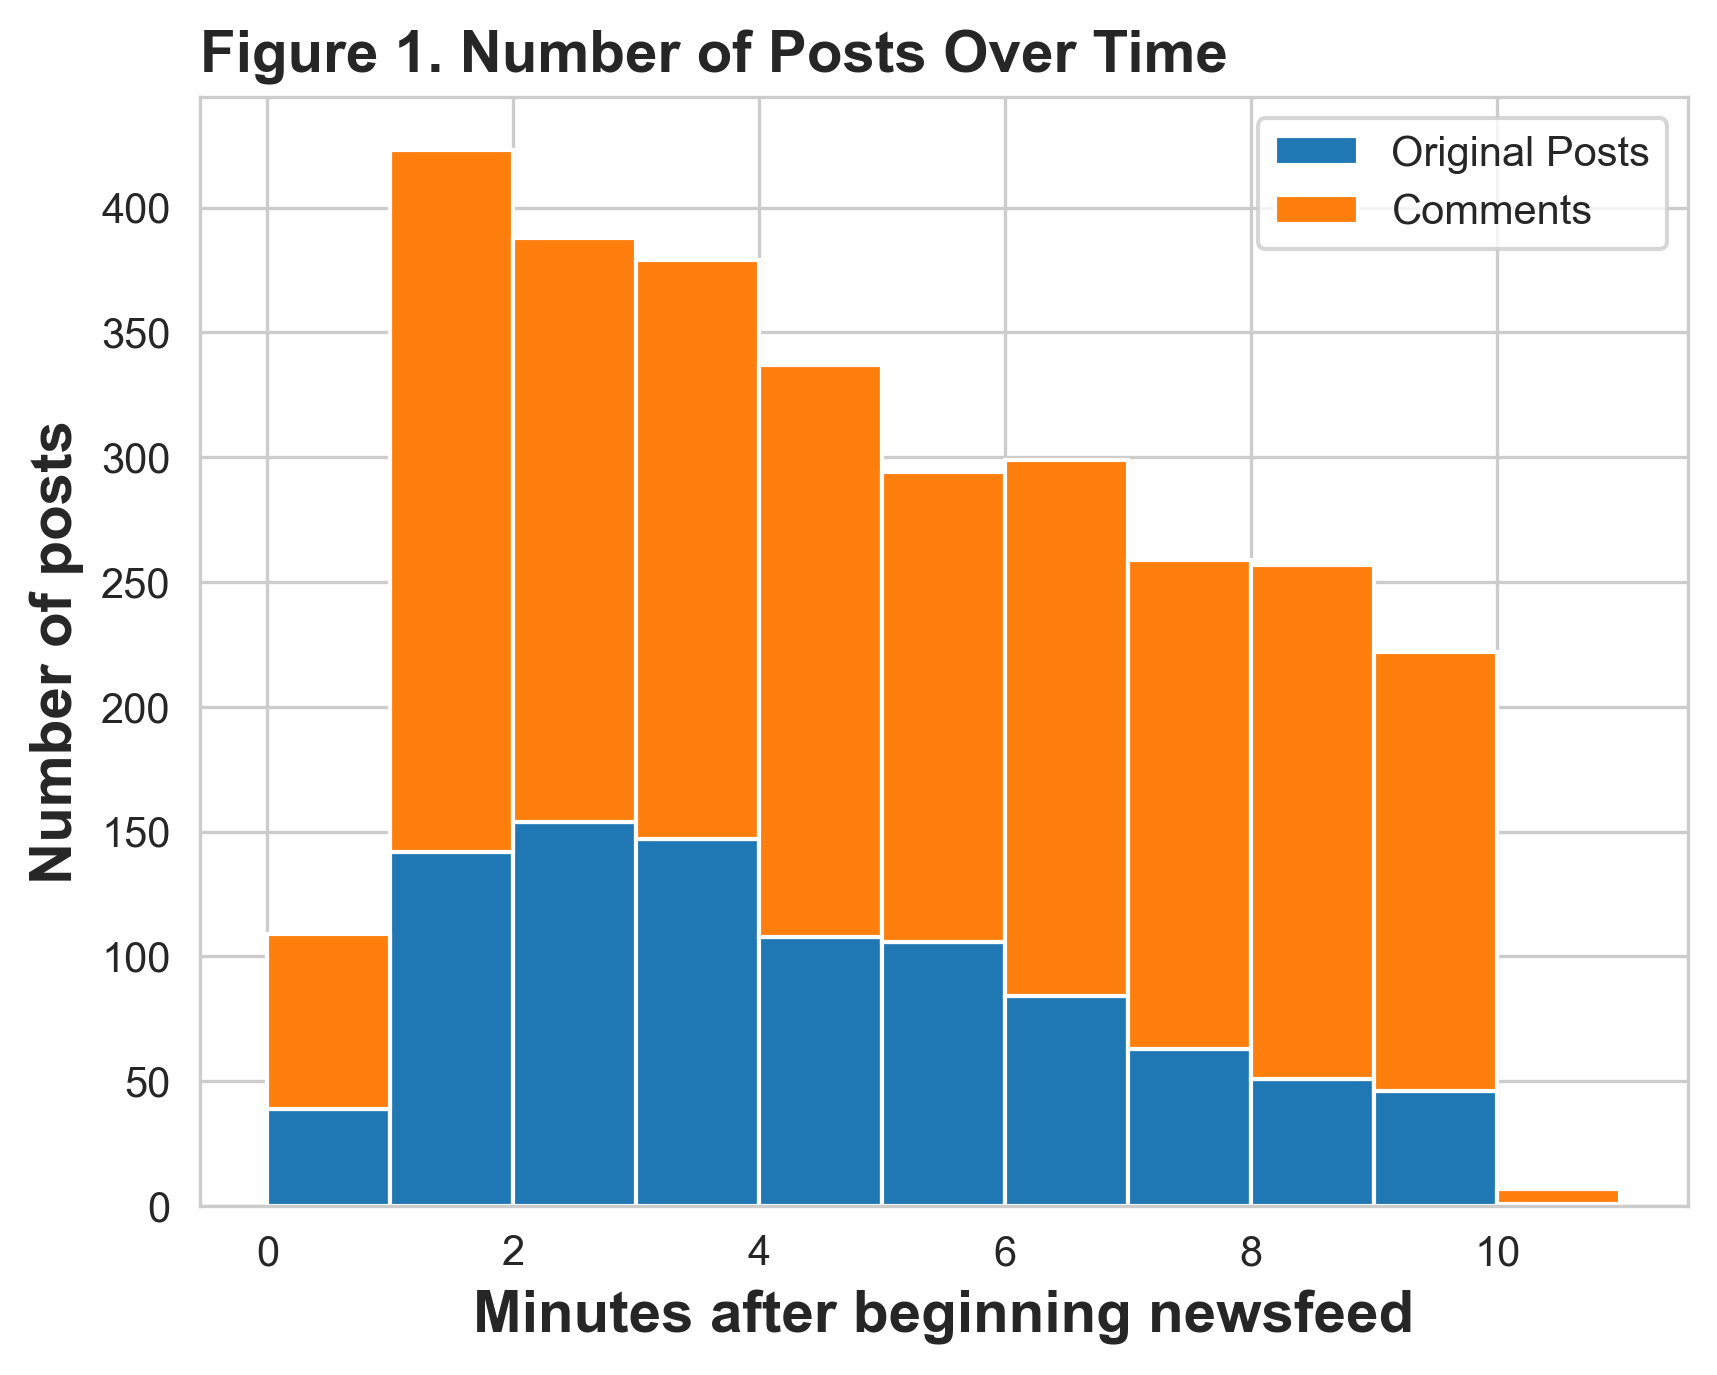

In [15]:
plt.figure(dpi=300)
sb.set_style("whitegrid")
plt.hist([op.rel_time, comments.rel_time],bins=[0,1,2,3,4,5,6,7,8,9,10,11], 
         label=["Original Posts", "Comments"], histtype="barstacked")
plt.xlabel("Minutes after beginning newsfeed", fontweight="bold",size=14)
plt.ylabel("Number of posts", fontweight="bold",size=14)
plt.legend()
plt.title("Figure 1. Number of Posts Over Time", loc="left", fontweight="bold",size=14)
plt.savefig("PostsOverTime.png")
plt.show()


In [16]:
content['minute'] = content.rel_time.apply(math.floor)
content[['minute','rel_time']].sort_values("rel_time")

,minute,rel_time
194,0,0.383333
1294,0,0.383333
2646,0,0.383333
3398,0,0.400000
254,0,0.433333
...,...,...
631,10,10.016667
1053,10,10.016667
1106,10,10.083333
3853,10,10.100000


In [17]:
t_df = content[content.minute == 3] 
t_df

,sessionId,treatmentArm,participantCode,profilePicture,firstName,lastName,bio,postOrCommentId,userContent,staticContent,...,IDENTITY_ATTACK_EXPERIMENTAL,INSULT_EXPERIMENTAL,PROFANITY_EXPERIMENTAL,THREAT_EXPERIMENTAL,SEXUALLY_EXPLICIT,FLIRTATION,perspective_toxicity_agg,tox,rel_time,minute
3,657896b96d158d001f181516,imm_treat,8gch37,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Yelena22,NaN,NC girl,657898246d158d001f18395d,1,0,...,0.277982,0.248355,0.045670,0.006965,0.009672,0.299508,0.150781,0.309935,3.883333,3
8,6578998a6d158d001f18687e,imm_control2,gw6r7f,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Carrann,NaN,"Love music, books, drawing",65789b506d158d001f18a0ee,1,0,...,0.001600,0.006401,0.010263,0.006337,0.004718,0.198480,0.029386,0.006629,3.816667,3
14,65789a9c6d158d001f187d86,imm_control1,hfyv7m,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Jazzy1122,NaN,I am a 26 year old female,65789c416d158d001f18eca6,1,0,...,0.057947,0.016557,0.015284,0.007262,0.005750,0.288662,0.060567,0.091122,3.450000,3
33,65789d776d158d001f195dcd,gc_control3,cw7ecf,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Dannadmw,NaN,I am 24f that is a SAHM with my 3 kids.,65789f136d158d001f1a043e,1,0,...,0.002211,0.012529,0.012859,0.023890,0.004748,0.328263,0.055151,0.054532,3.516667,3
36,65789dbc6d158d001f198143,gc_control3,be7fp8,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,mjgeep,NaN,swaggin since birth,65789f566d158d001f1a1d5c,1,0,...,0.006105,0.008140,0.017299,0.008363,0.013093,0.183603,0.032155,0.019226,3.100000,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4377,657b50552855e7001f8dad43,imm_control3,dd2rvg,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Benson12,NaN,"I am good-looking, I am a father of 2 boys. I ...",657b52ef2855e7001f912d40,1,0,...,0.003478,0.007703,0.014703,0.007495,0.010970,0.160072,0.027396,0.013509,3.533333,3
4383,657b50788b12dc001fffbcae,imm_control3,11frdz,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Jlynn,NaN,"Northern Michigan mom, book reader, master of HR.",657b52408b12dc001f0250ed,1,0,...,0.042293,0.014961,0.011663,0.006492,0.003347,0.381433,0.064106,0.051069,3.950000,3
4384,657b55bb2855e7001f928abe,imm_control3,uewkay,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,smith,NaN,I play chess,657b57368b12dc001f04a647,1,0,...,0.002682,0.007247,0.012722,0.007016,0.008552,0.181107,0.028821,0.010241,3.116667,3
4386,657b58d12855e7001f932c5f,imm_control3,qby6gb,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,helloyello1234,NaN,I love to play disc golf and I love to go fish...,657b5a392855e7001f935f31,1,0,...,0.027414,0.012567,0.013713,0.007366,0.006458,0.201886,0.040559,0.053048,3.650000,3


In [18]:
t_df[["participantCode","condition", "ih", "tox"]].groupby(["participantCode","condition"]).mean().reset_index()

,participantCode,condition,ih,tox
0,11b468,treat,0.250499,0.052058
1,11frdz,control,0.522249,0.051069
2,12cpx2,control,0.110547,0.396442
3,16rhru,treat,0.495928,0.099589
4,1f4cwc,control,0.293944,0.288572
...,...,...,...,...
356,zu9wre,control,0.351776,0.050079
357,zv3m1r,control,0.124832,0.082417
358,zwphpx,control,0.156862,0.071683
359,zxyz1h,control,0.374476,0.098626


In [19]:
t_df[t_df.participantCode == "11b468"].ih

3519    0.250499
Name: ih, dtype: float64

In [20]:
betas_ih = []
betas_tox = []
cis_ih = []
cis_tox = []
ts = [i for i in range(10)]

for t in ts:
    t_df = content[content.minute == t] 
    n_messages = len(t_df)
    t_df = t_df[["participantCode","condition", "ih", "tox"]].groupby(["participantCode","condition"]).mean().reset_index()
    n_users = len(t_df)
    print(t, n_messages, n_users)

    #t_df.ih = (t_df.ih - t_df.ih.mean())/t_df.ih.std()
    #t_df.tox = (t_df.tox - t_df.tox.mean())/t_df.tox.std()
    
    #betas_ih.append(t_df[t_df.condition == "treat"].ih.mean() - t_df[t_df.condition == "control"].ih.mean())
    
    #boots_ih = []
    #for s in range(2500):
    #    boot = t_df.sample(frac=1, replace=True)
    #    boots_ih.append(boot[boot.condition == "treat"].ih.mean() - boot[boot.condition == "control"].ih.mean())
    #cis_ih.append(np.quantile(boots_ih, (0.025, 0.975)))

    #betas_tox.append(t_df[t_df.condition == "treat"].tox.mean() - t_df[t_df.condition == "control"].tox.mean())
    
    #boots_tox = []
    #for s in range(2500):
    #    boot = t_df.sample(frac=1, replace=True)
    #    boots_tox.append(boot[boot.condition == "treat"].tox.mean() - boot[boot.condition == "control"].tox.mean())
    #cis_tox.append(np.quantile(boots_tox, (0.025, 0.975)))

0 109 105
1 423 382
2 388 362
3 379 361
4 337 322
5 294 273
6 299 286
7 259 236
8 257 236
9 222 210


In [21]:
betas_ih = []
betas_tox = []
cis_ih = []
cis_tox = []
ts = [i for i in range(10)]

for t in ts:
    t_df = content[content.minute == t] 
    t_df = t_df[["participantCode","condition", "ih", "tox"]].groupby(["participantCode","condition"]).mean().reset_index()

    t_df.ih = (t_df.ih - t_df.ih.mean())/t_df.ih.std()
    t_df.tox = (t_df.tox - t_df.tox.mean())/t_df.tox.std()
    
    betas_ih.append(t_df[t_df.condition == "treat"].ih.mean() - t_df[t_df.condition == "control"].ih.mean())
    
    boots_ih = []
    for s in range(2500):
        boot = t_df.sample(frac=1, replace=True)
        boots_ih.append(boot[boot.condition == "treat"].ih.mean() - boot[boot.condition == "control"].ih.mean())
    cis_ih.append(np.quantile(boots_ih, (0.025, 0.975)))

    betas_tox.append(t_df[t_df.condition == "treat"].tox.mean() - t_df[t_df.condition == "control"].tox.mean())
    
    boots_tox = []
    for s in range(2500):
        boot = t_df.sample(frac=1, replace=True)
        boots_tox.append(boot[boot.condition == "treat"].tox.mean() - boot[boot.condition == "control"].tox.mean())
    cis_tox.append(np.quantile(boots_tox, (0.025, 0.975)))

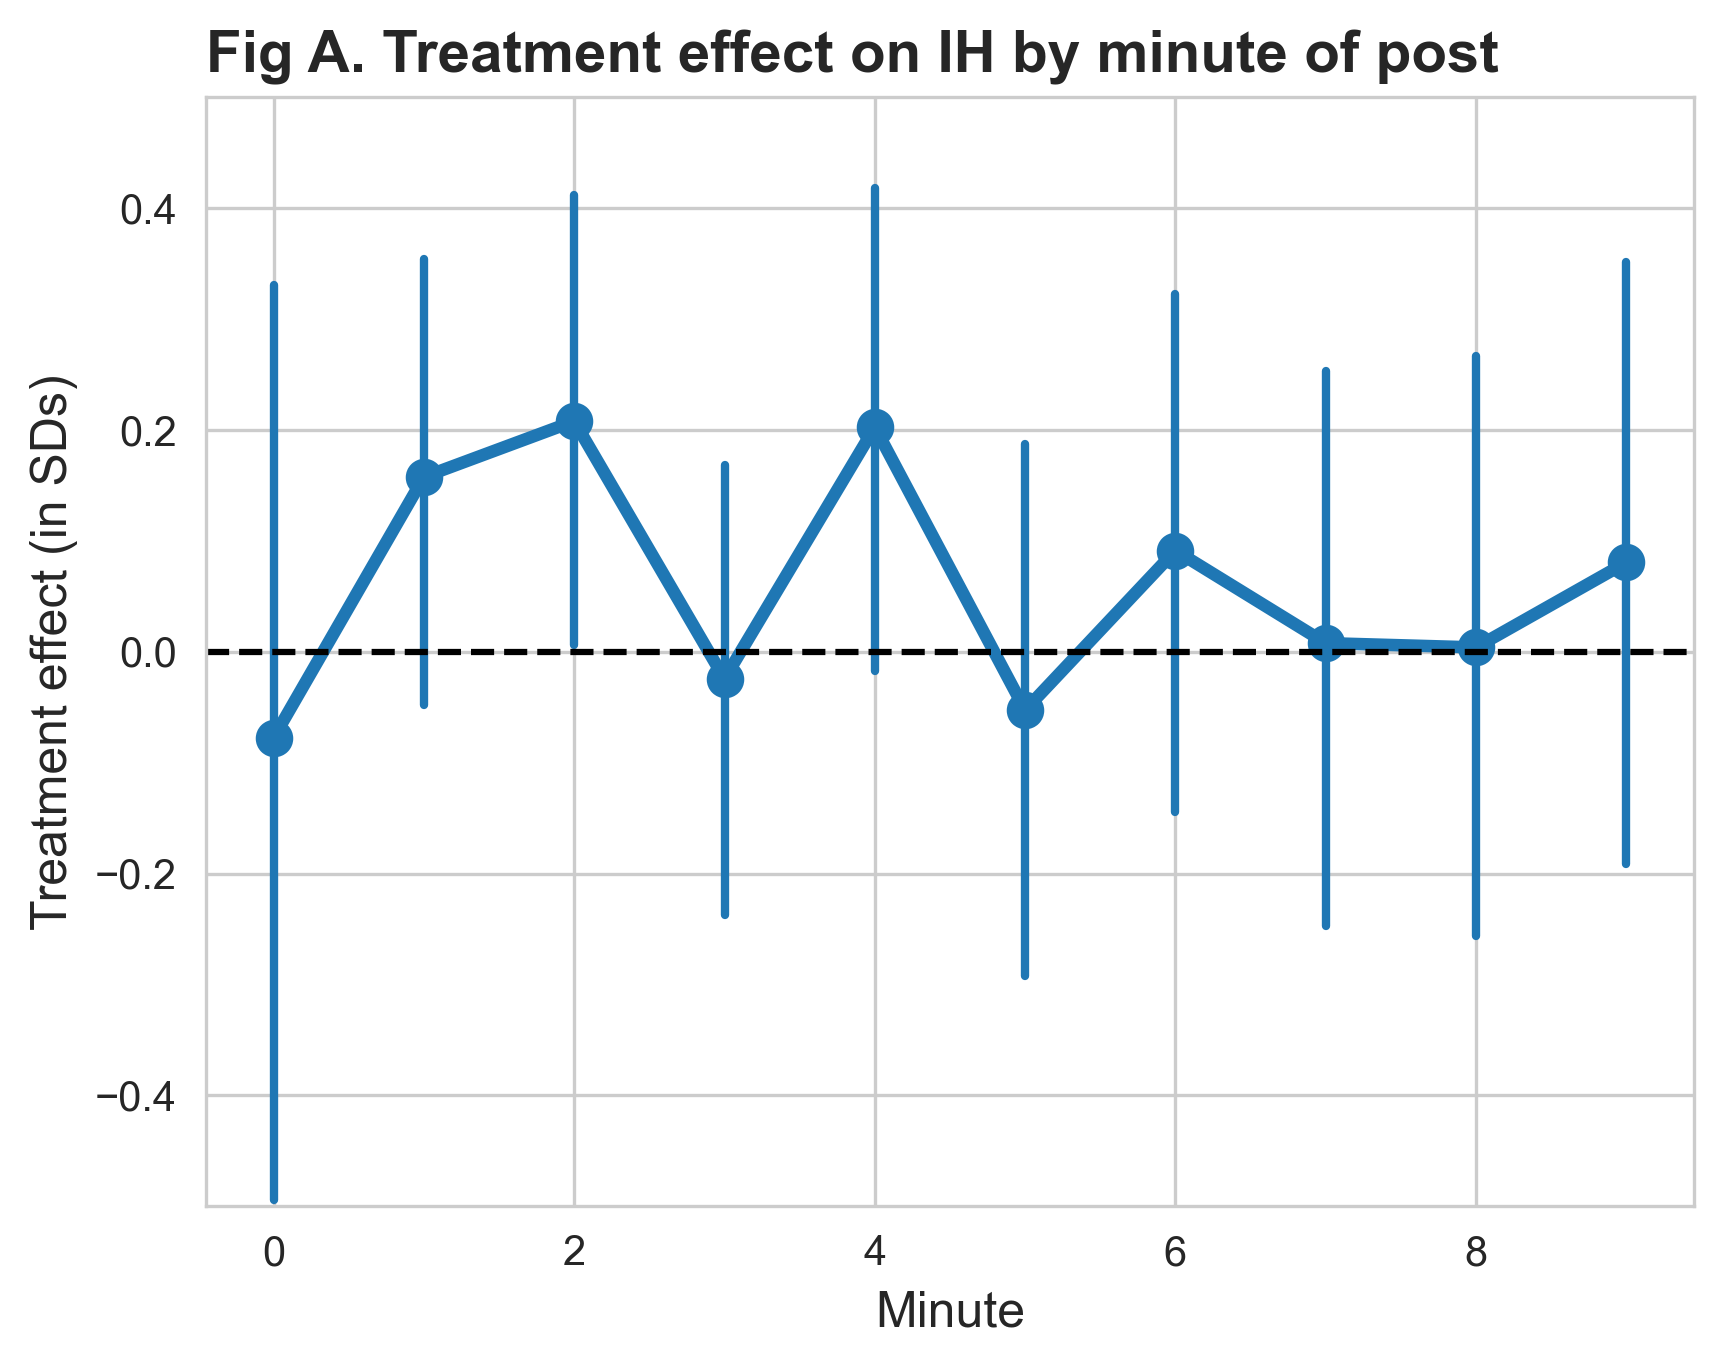

In [22]:
plt.figure(dpi=300)
plt.ylim(-0.5, 0.5)
plt.plot(ts, betas_ih, lw=3, c="tab:blue", label="IH")
plt.scatter(ts, betas_ih, lw=3, c="tab:blue")
for t in ts:
    plt.plot([t,t], cis_ih[t], color="tab:blue", lw=2)
plt.axhline(0, ls="--", color="black")
plt.title(r"Fig A. Treatment effect on IH by minute of post", loc="left", size=14, weight="bold")
plt.xlabel("Minute", size=12)
plt.ylabel("Treatment effect (in SDs)", size=12)
plt.savefig("TimeBucketIH.png", dpi=300)
plt.show()

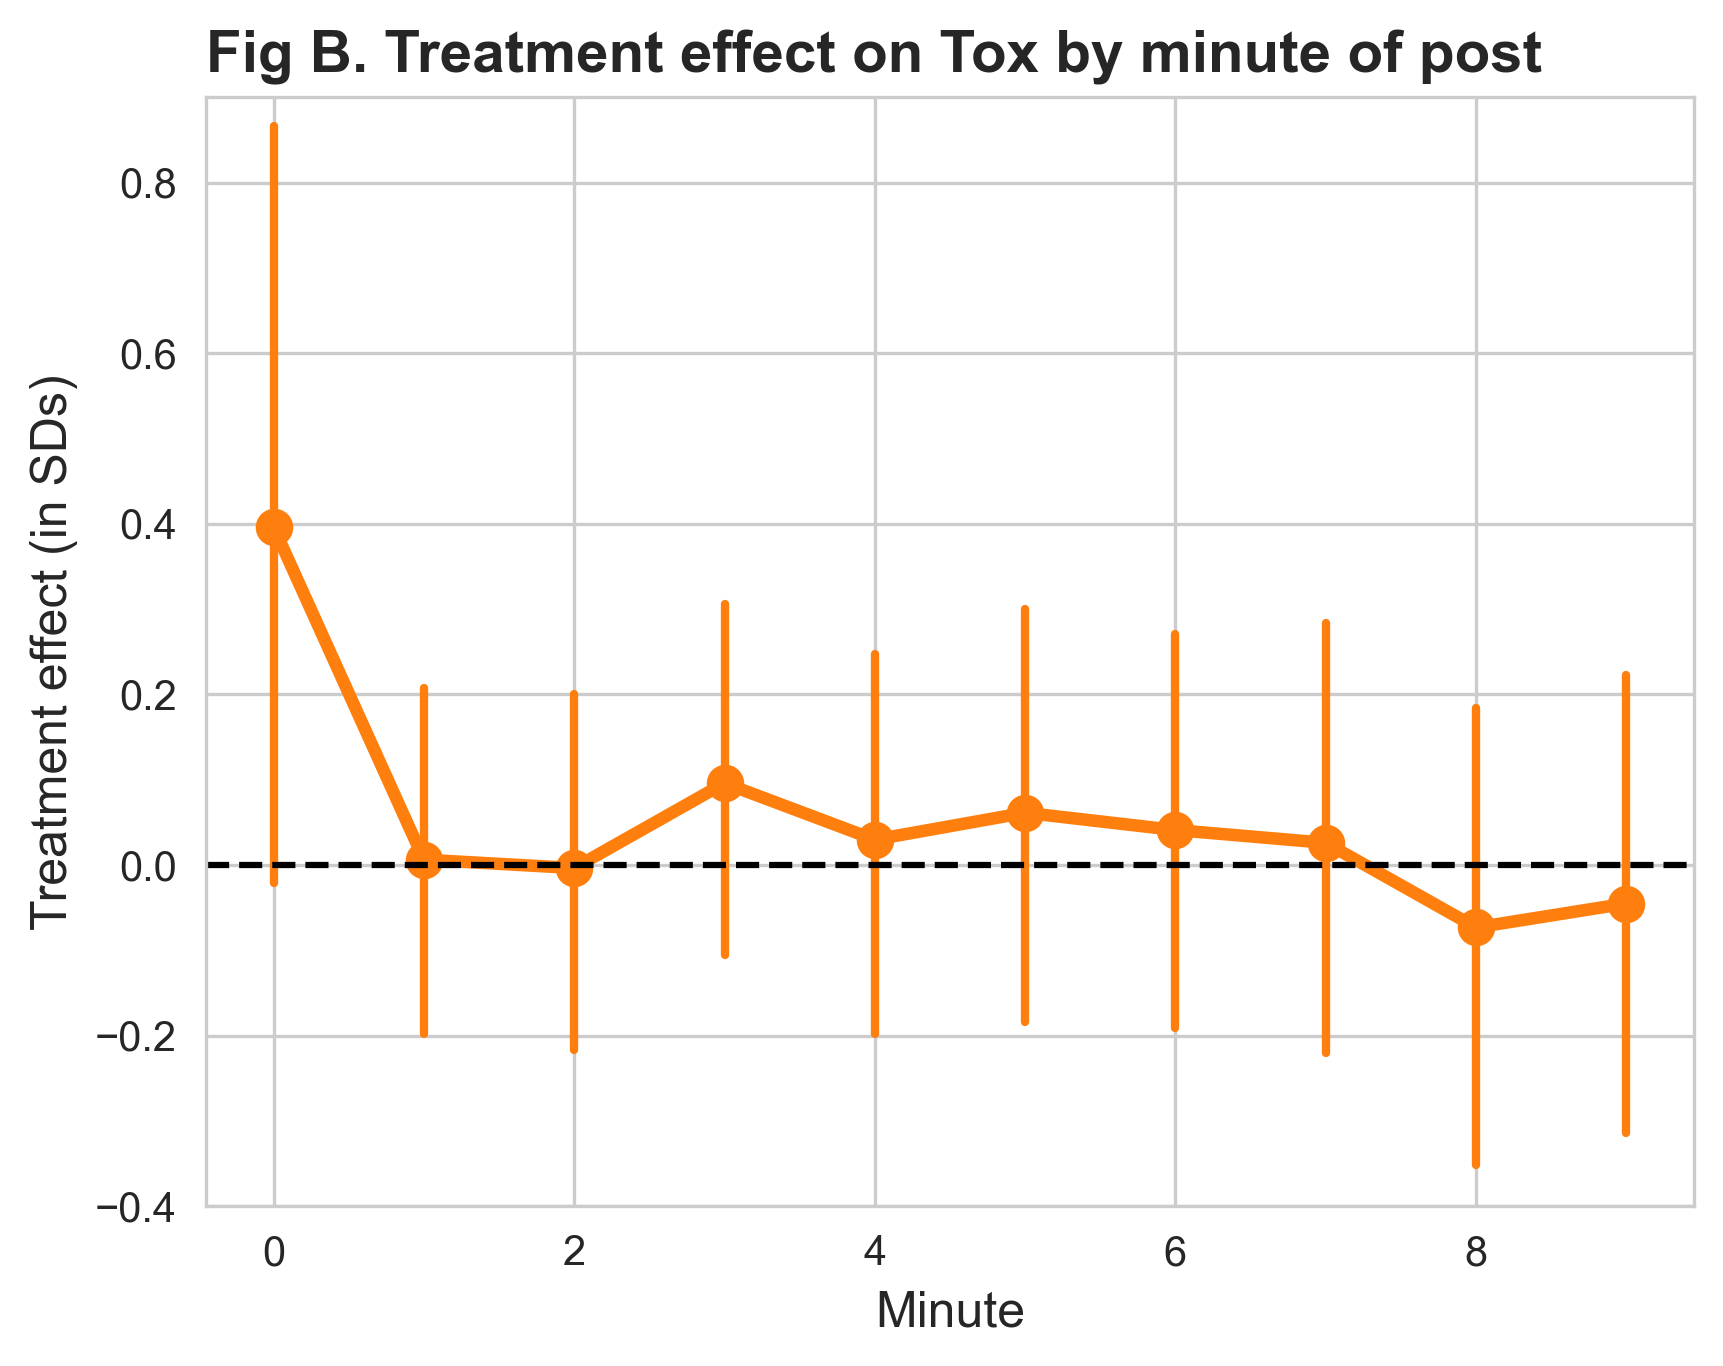

In [23]:
plt.figure(dpi=300)
plt.ylim(-0.4, 0.9)
plt.plot(ts, betas_tox, lw=3, c="tab:orange", label="Tox")
plt.scatter(ts, betas_tox, lw=3, c="tab:orange")
for t in ts:
    plt.plot([t,t], cis_tox[t], color="tab:orange", lw=2)
plt.axhline(0, ls="--", color="black")
plt.title(r"Fig B. Treatment effect on Tox by minute of post", loc="left", size=14, weight="bold")
plt.xlabel("Minute", size=12)
plt.ylabel("Treatment effect (in SDs)", size=12)
plt.savefig("TimeBucketTox.png", dpi=300)
plt.show()

In [43]:
n_messages = []
n_users = []
ts = [i/10 for i in range(0,95,5)]

for t in ts:
    t_df = content[content.rel_time >= t] 
    n_messages.append(len(t_df))
    t_df = t_df[["participantCode","condition", "ih", "tox"]].groupby(["participantCode","condition"]).mean().reset_index()
    n_users.append(len(t_df))

print(t, n_messages, n_users)

9.0 [2974, 2963, 2865, 2648, 2442, 2258, 2054, 1866, 1675, 1515, 1338, 1199, 1044, 892, 745, 629, 486, 357, 229] [981, 981, 978, 956, 933, 910, 880, 839, 807, 760, 707, 671, 631, 572, 507, 456, 392, 311, 214]


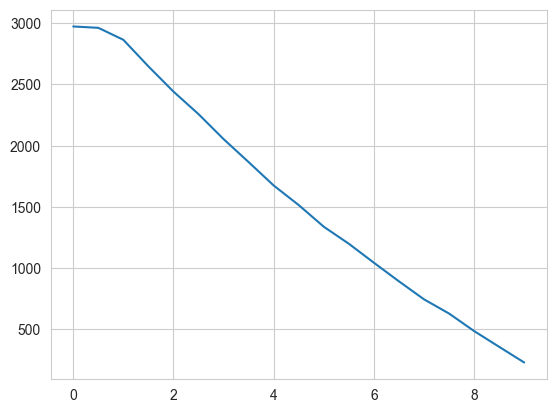

In [44]:
plt.plot(ts, n_messages)

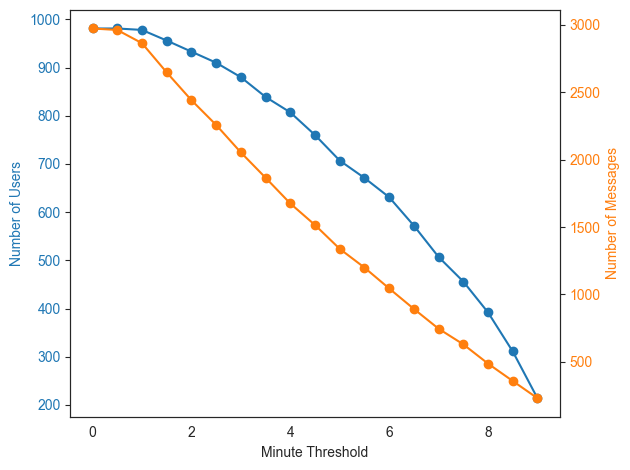

In [45]:
sb.set_style("white")
fig, ax1 = plt.subplots()

color = 'tab:blue'
ax1.set_xlabel('Minute Threshold')
ax1.set_ylabel('Number of Users', color=color)
ax1.plot(ts, n_users, color=color)
ax1.scatter(ts, n_users, color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:orange'
ax2.set_ylabel('Number of Messages', color=color)  # we already handled the x-label with ax1
ax2.plot(ts, n_messages, color=color)
ax2.scatter(ts, n_messages, color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.savefig("AblationTestN.png", dpi=300)
plt.show()

In [27]:
betas_ih = []
betas_tox = []
cis_ih = []
cis_tox = []
ts = [i/10 for i in range(0,95,5)]

for t in ts:
    t_df = content[content.rel_time >= t] 
    t_df = t_df[["participantCode","condition", "ih"]].groupby(["participantCode","condition"]).mean().reset_index()

    t_df.ih = (t_df.ih - t_df.ih.mean())/t_df.ih.std()
    
    betas_ih.append(t_df[t_df.condition == "treat"].ih.mean() - t_df[t_df.condition == "control"].ih.mean())
    
    boots_ih = []
    for s in range(5000):
        boot = t_df.sample(frac=1, replace=True)
        boots_ih.append(boot[boot.condition == "treat"].ih.mean() - boot[boot.condition == "control"].ih.mean())
    cis_ih.append(np.quantile(boots_ih, (0.025, 0.975)))

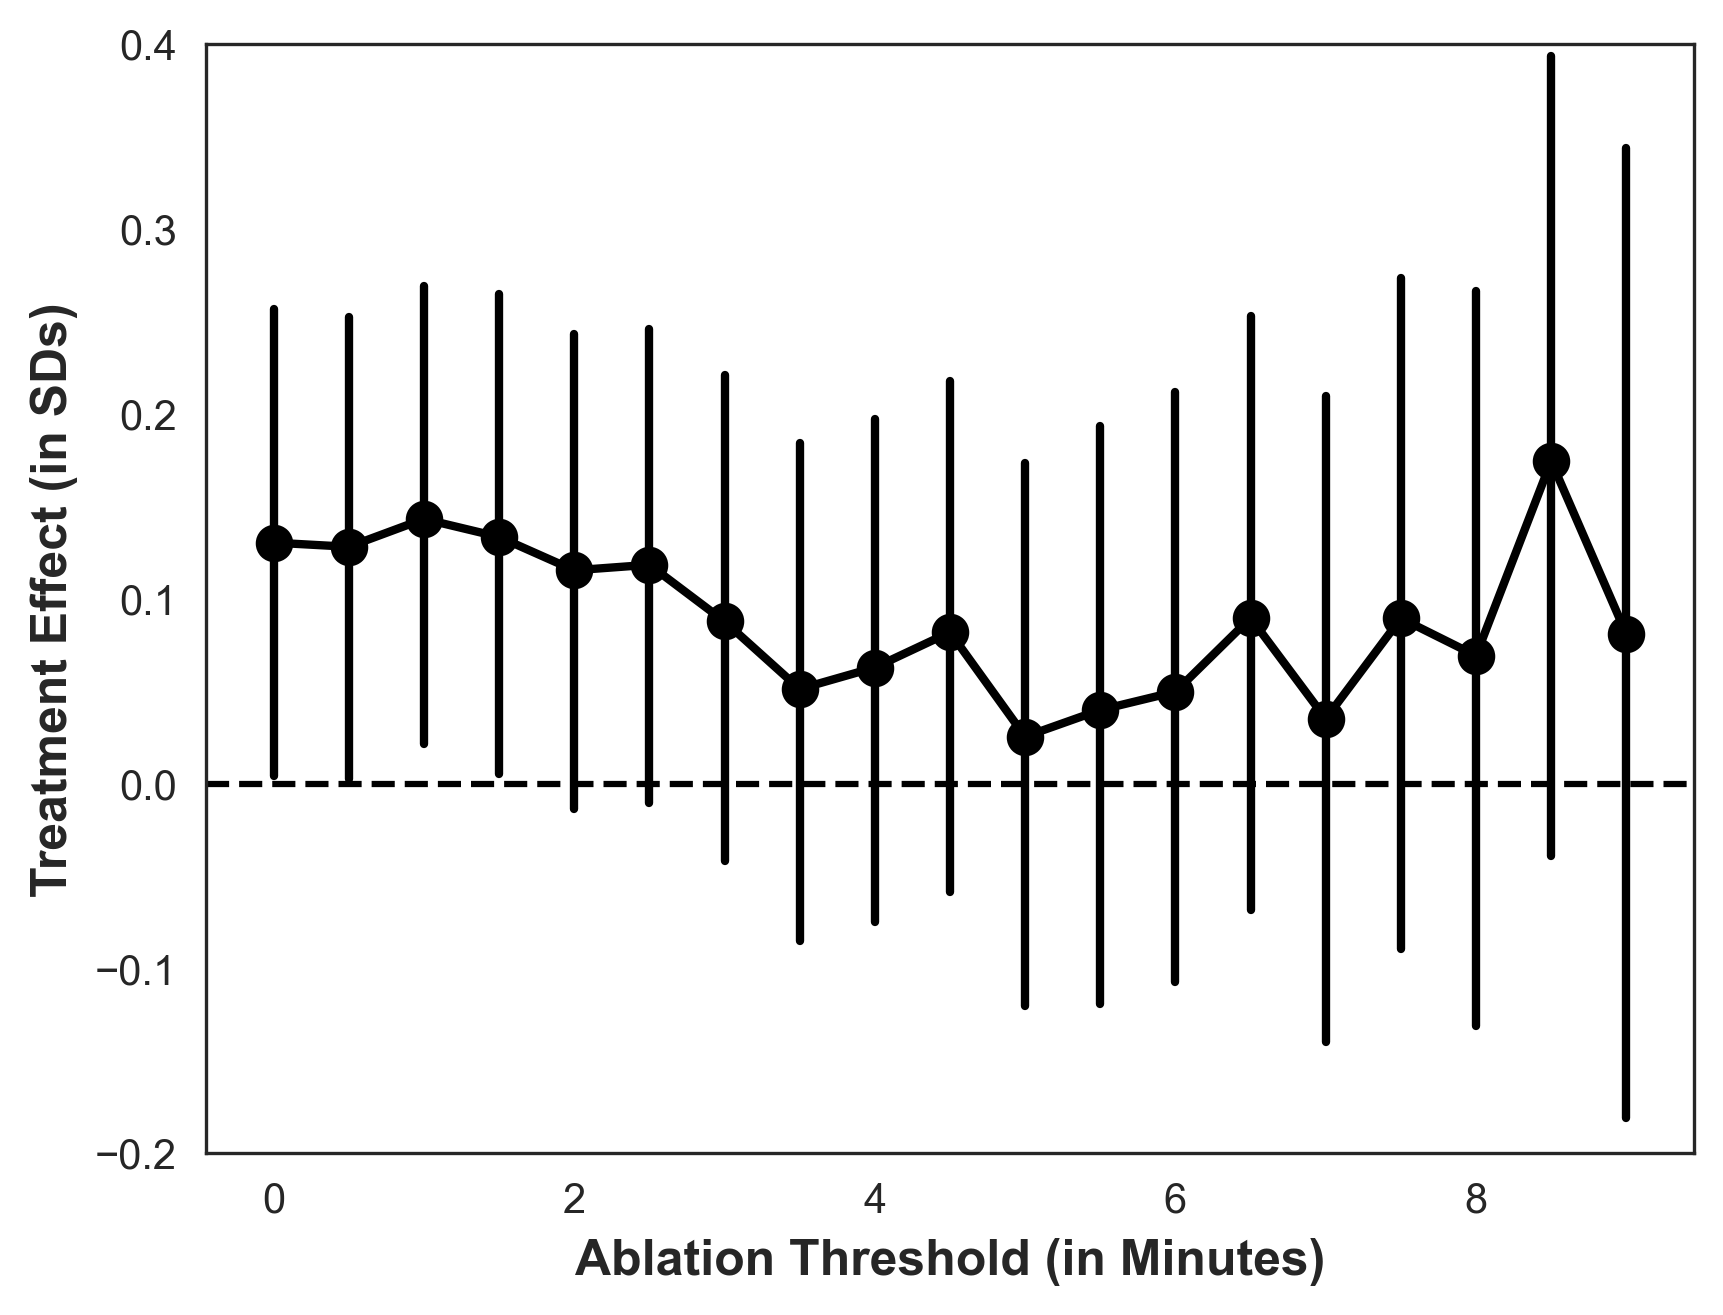

In [50]:
sb.set_style("white")
plt.figure(dpi=300)
plt.ylim(-0.2,0.4)
plt.plot(ts, betas_ih, lw=2, c="black", label="IH")
plt.scatter(ts, betas_ih, lw=3, c="black")
for i, t in enumerate(ts):
    plt.plot([t,t], cis_ih[i], color="black", lw=2)
plt.axhline(0, ls="--", color="black")
#plt.title(r"Fig C. Ablation Test of the Treatment Effect on IH", loc="left", size=14, weight="bold")
plt.xlabel("Ablation Threshold (in Minutes)", size=12, fontweight="bold")
plt.ylabel("Treatment Effect (in SDs)", size=12, fontweight="bold")
plt.savefig("AblationTestFig.png", dpi=300)
plt.show()

In [47]:
[i for i in zip(ts, n_users)]

[(0.0, 981),
 (0.5, 981),
 (1.0, 978),
 (1.5, 956),
 (2.0, 933),
 (2.5, 910),
 (3.0, 880),
 (3.5, 839),
 (4.0, 807),
 (4.5, 760),
 (5.0, 707),
 (5.5, 671),
 (6.0, 631),
 (6.5, 572),
 (7.0, 507),
 (7.5, 456),
 (8.0, 392),
 (8.5, 311),
 (9.0, 214)]

In [35]:
cis_ih

[array([0.00670425, 0.25493981]),
 array([0.00284374, 0.25411367]),
 array([0.01789782, 0.2681865 ]),
 array([0.00796457, 0.25668346]),
 array([-0.01368812,  0.23918306]),
 array([-0.01258761,  0.2490179 ]),
 array([-0.04032148,  0.21867984]),
 array([-0.08326022,  0.18432588]),
 array([-0.07447197,  0.20094901]),
 array([-0.05810986,  0.22544668]),
 array([-0.11902691,  0.17408553]),
 array([-0.11708748,  0.19115296]),
 array([-0.09974176,  0.20731577]),
 array([-0.07591955,  0.25258154]),
 array([-0.13860915,  0.20703119]),
 array([-0.09974306,  0.27168819]),
 array([-0.12581194,  0.27183861]),
 array([-0.04585194,  0.39100212]),
 array([-0.1927061 ,  0.34733001])]

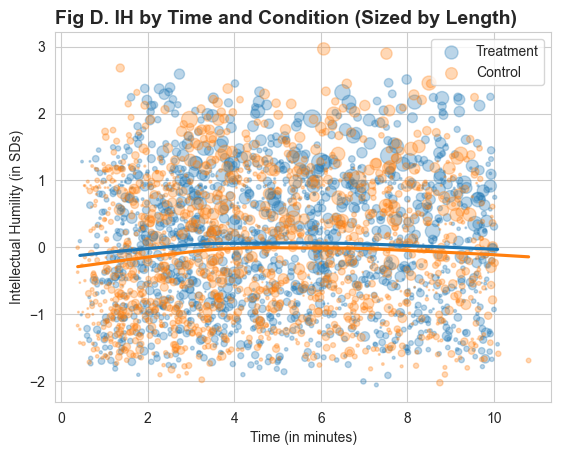

In [215]:
content['ih'] = (content.ih - content.ih.mean())/content.ih.std()

sb.regplot(x=content[content.condition=="treat"].rel_time, 
            y=content[content.condition=="treat"].ih, 
           label="Treatment", lowess=True,
          scatter_kws = {"s": content[content.condition=="treat"].length/5, 
                         "alpha": 0.3})
sb.regplot(x=content[content.condition=="control"].rel_time, 
            y=content[content.condition=="control"].ih, 
           label="Control", lowess=True,
          scatter_kws = {"s": content[content.condition=="control"].length/5,
                         "alpha": 0.3})
plt.legend()
plt.title(r"Fig D. IH by Time and Condition (Sized by Length)", loc="left", size=14, weight="bold")
plt.xlabel("Time (in minutes)")
plt.ylabel("Intellectual Humility (in SDs)")
plt.savefig("ihTime.png",dpi=300)
plt.show()

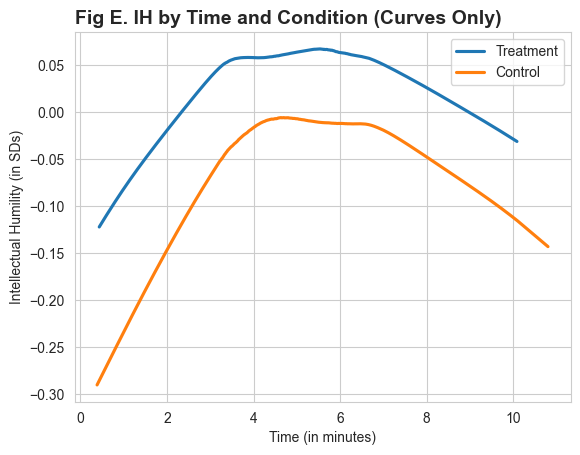

In [214]:
content['ih'] = (content.ih - content.ih.mean())/content.ih.std()

sb.regplot(x=content[content.condition=="treat"].rel_time, 
            y=content[content.condition=="treat"].ih, 
           label="Treatment", lowess=True,
          scatter=False)
sb.regplot(x=content[content.condition=="control"].rel_time, 
            y=content[content.condition=="control"].ih, 
           label="Control", lowess=True,
          scatter=False)
plt.legend()
plt.title(r"Fig E. IH by Time and Condition (Curves Only)", loc="left", size=14, weight="bold")
plt.xlabel("Time (in minutes)")
plt.ylabel("Intellectual Humility (in SDs)")
plt.savefig("ihTime2.png",dpi=300)
plt.show()

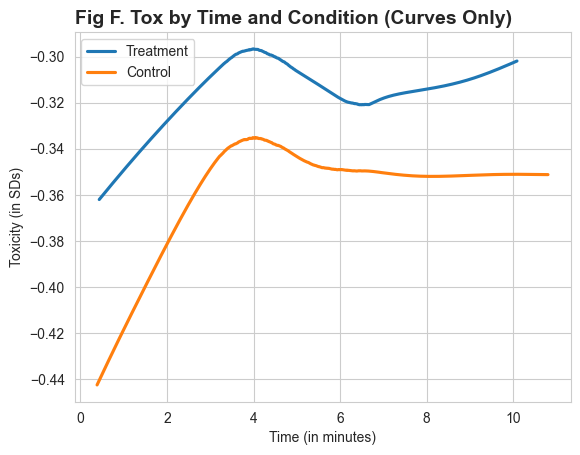

In [239]:
content['tox'] = (content.tox - content.tox.mean())/content.tox.std()

sb.regplot(x=content[content.condition=="treat"].rel_time, 
            y=content[content.condition=="treat"].tox, 
           label="Treatment", lowess=True,
          scatter=False)
sb.regplot(x=content[content.condition=="control"].rel_time, 
            y=content[content.condition=="control"].tox, 
           label="Control", lowess=True,
          scatter=False)
plt.legend()
plt.title(r"Fig F. Tox by Time and Condition (Curves Only)", loc="left", size=14, weight="bold")
plt.xlabel("Time (in minutes)")
plt.ylabel("Toxicity (in SDs)")
#plt.savefig("ihTime2.png",dpi=300)
plt.show()

In [197]:
content.columns.to_list()

['sessionId',
 'treatmentArm',
 'participantCode',
 'profilePicture',
 'firstName',
 'lastName',
 'bio',
 'postOrCommentId',
 'userContent',
 'staticContent',
 'dynamicContent',
 'postOrCommentText',
 'postOrCommentDate',
 'postLikes',
 'postDislikes',
 'participantLiked',
 'participantDisliked',
 'parentPost',
 'previousCommentOrPost',
 'dwellTimeInSeconds',
 'condition',
 'ih',
 'AFFINITY_EXPERIMENTAL',
 'COMPASSION_EXPERIMENTAL',
 'CURIOSITY_EXPERIMENTAL',
 'NUANCE_EXPERIMENTAL',
 'PERSONAL_STORY_EXPERIMENTAL',
 'REASONING_EXPERIMENTAL',
 'RESPECT_EXPERIMENTAL',
 'TOXICITY_EXPERIMENTAL',
 'SEVERE_TOXICITY_EXPERIMENTAL',
 'IDENTITY_ATTACK_EXPERIMENTAL',
 'INSULT_EXPERIMENTAL',
 'PROFANITY_EXPERIMENTAL',
 'THREAT_EXPERIMENTAL',
 'SEXUALLY_EXPLICIT',
 'FLIRTATION',
 'perspective_toxicity_agg',
 'tox',
 'rel_time',
 'minute']

In [198]:
content['length'] = content.postOrCommentText.apply(len)

In [242]:
stats.pearsonr(content.length, content.tox)

PearsonRResult(statistic=0.16409648095274934, pvalue=2.132147437939759e-19)

In [244]:
new_df = content[["participantCode","condition", "ih", "length", "tox"]].groupby(["participantCode","condition"]).mean().reset_index()

In [245]:
stats.pearsonr(new_df.length, new_df.tox)

PearsonRResult(statistic=0.16593553270709413, pvalue=1.72372175431581e-07)

In [246]:
new_df = new_df.merge(participants, left_on="participantCode", right_on="participant_code", validate="1:1")

In [225]:
new_df

,participantCode,condition_x,ih,length,StartDate_post,EndDate_post,Status_post,IPAddress_post,Progress_post,Duration (in seconds)_post,...,ih_dwell_p,mc_correct,n_op,n_comments,zip_state_match,speeder,commented,posted,passcode,gold_star
0,11b468,treat,-0.488512,242.333333,12/14/2023 11:54,12/14/2023 11:59,IP Address,104.63.192.16,100,248,...,0.147813,1,1,2,1,1,1,1,True,1
1,11frdz,control,-0.430575,122.750000,12/14/2023 12:12,12/14/2023 12:19,IP Address,47.50.90.2,100,407,...,NaN,0,1,3,1,1,1,1,True,0
2,11g3d4,treat,-1.676060,48.000000,12/12/2023 11:49,12/12/2023 11:58,IP Address,192.161.78.131,100,532,...,0.225434,1,1,0,1,1,1,0,True,0
3,11uby7,treat,-0.487835,201.000000,12/14/2023 12:03,12/14/2023 12:06,IP Address,98.233.89.114,100,190,...,0.153023,1,1,1,1,1,1,1,True,1
4,12cpx2,control,-0.471911,82.750000,12/14/2023 11:06,12/14/2023 11:09,IP Address,76.129.156.69,100,161,...,NaN,1,2,10,1,1,1,1,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
976,zxyz1h,control,-0.469323,34.250000,12/14/2023 9:17,12/14/2023 9:23,IP Address,66.177.145.189,100,377,...,0.297755,1,3,13,1,1,1,1,True,1
977,zy6tqc,treat,0.338553,58.100000,12/14/2023 9:34,12/14/2023 9:38,IP Address,74.73.253.203,100,241,...,0.057024,1,3,7,1,1,1,1,True,1
978,zywuwt,control,-0.779809,30.333333,12/13/2023 11:12,12/13/2023 11:22,IP Address,35.147.55.143,100,563,...,0.005521,1,1,2,1,1,1,1,True,1
979,zzmpme,control,-0.496483,93.000000,12/12/2023 11:28,12/12/2023 11:30,IP Address,24.1.54.200,100,146,...,0.209302,1,1,0,1,0,1,0,True,0


In [247]:
new_df = new_df.dropna(subset=["pre_ih","ih"])

In [251]:
stats.pearsonr(new_df.pre_ih, new_df.tox)

PearsonRResult(statistic=-0.06493283445357648, pvalue=0.04212633559609435)

In [252]:
stats.pearsonr(new_df.post_ih, new_df.tox)

PearsonRResult(statistic=-0.08520047806773205, pvalue=0.007615755103156111)

In [254]:
stats.pearsonr(new_df.delta_ih, new_df.tox)

PearsonRResult(statistic=-0.047615531092863386, pvalue=0.13634406408200825)

In [255]:
stats.pearsonr(new_df.tox, new_df.ih)

PearsonRResult(statistic=-0.31169810773042006, pvalue=1.598036841912645e-23)